In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from PIL import Image

In [2]:
data = pd.read_csv("data.csv")

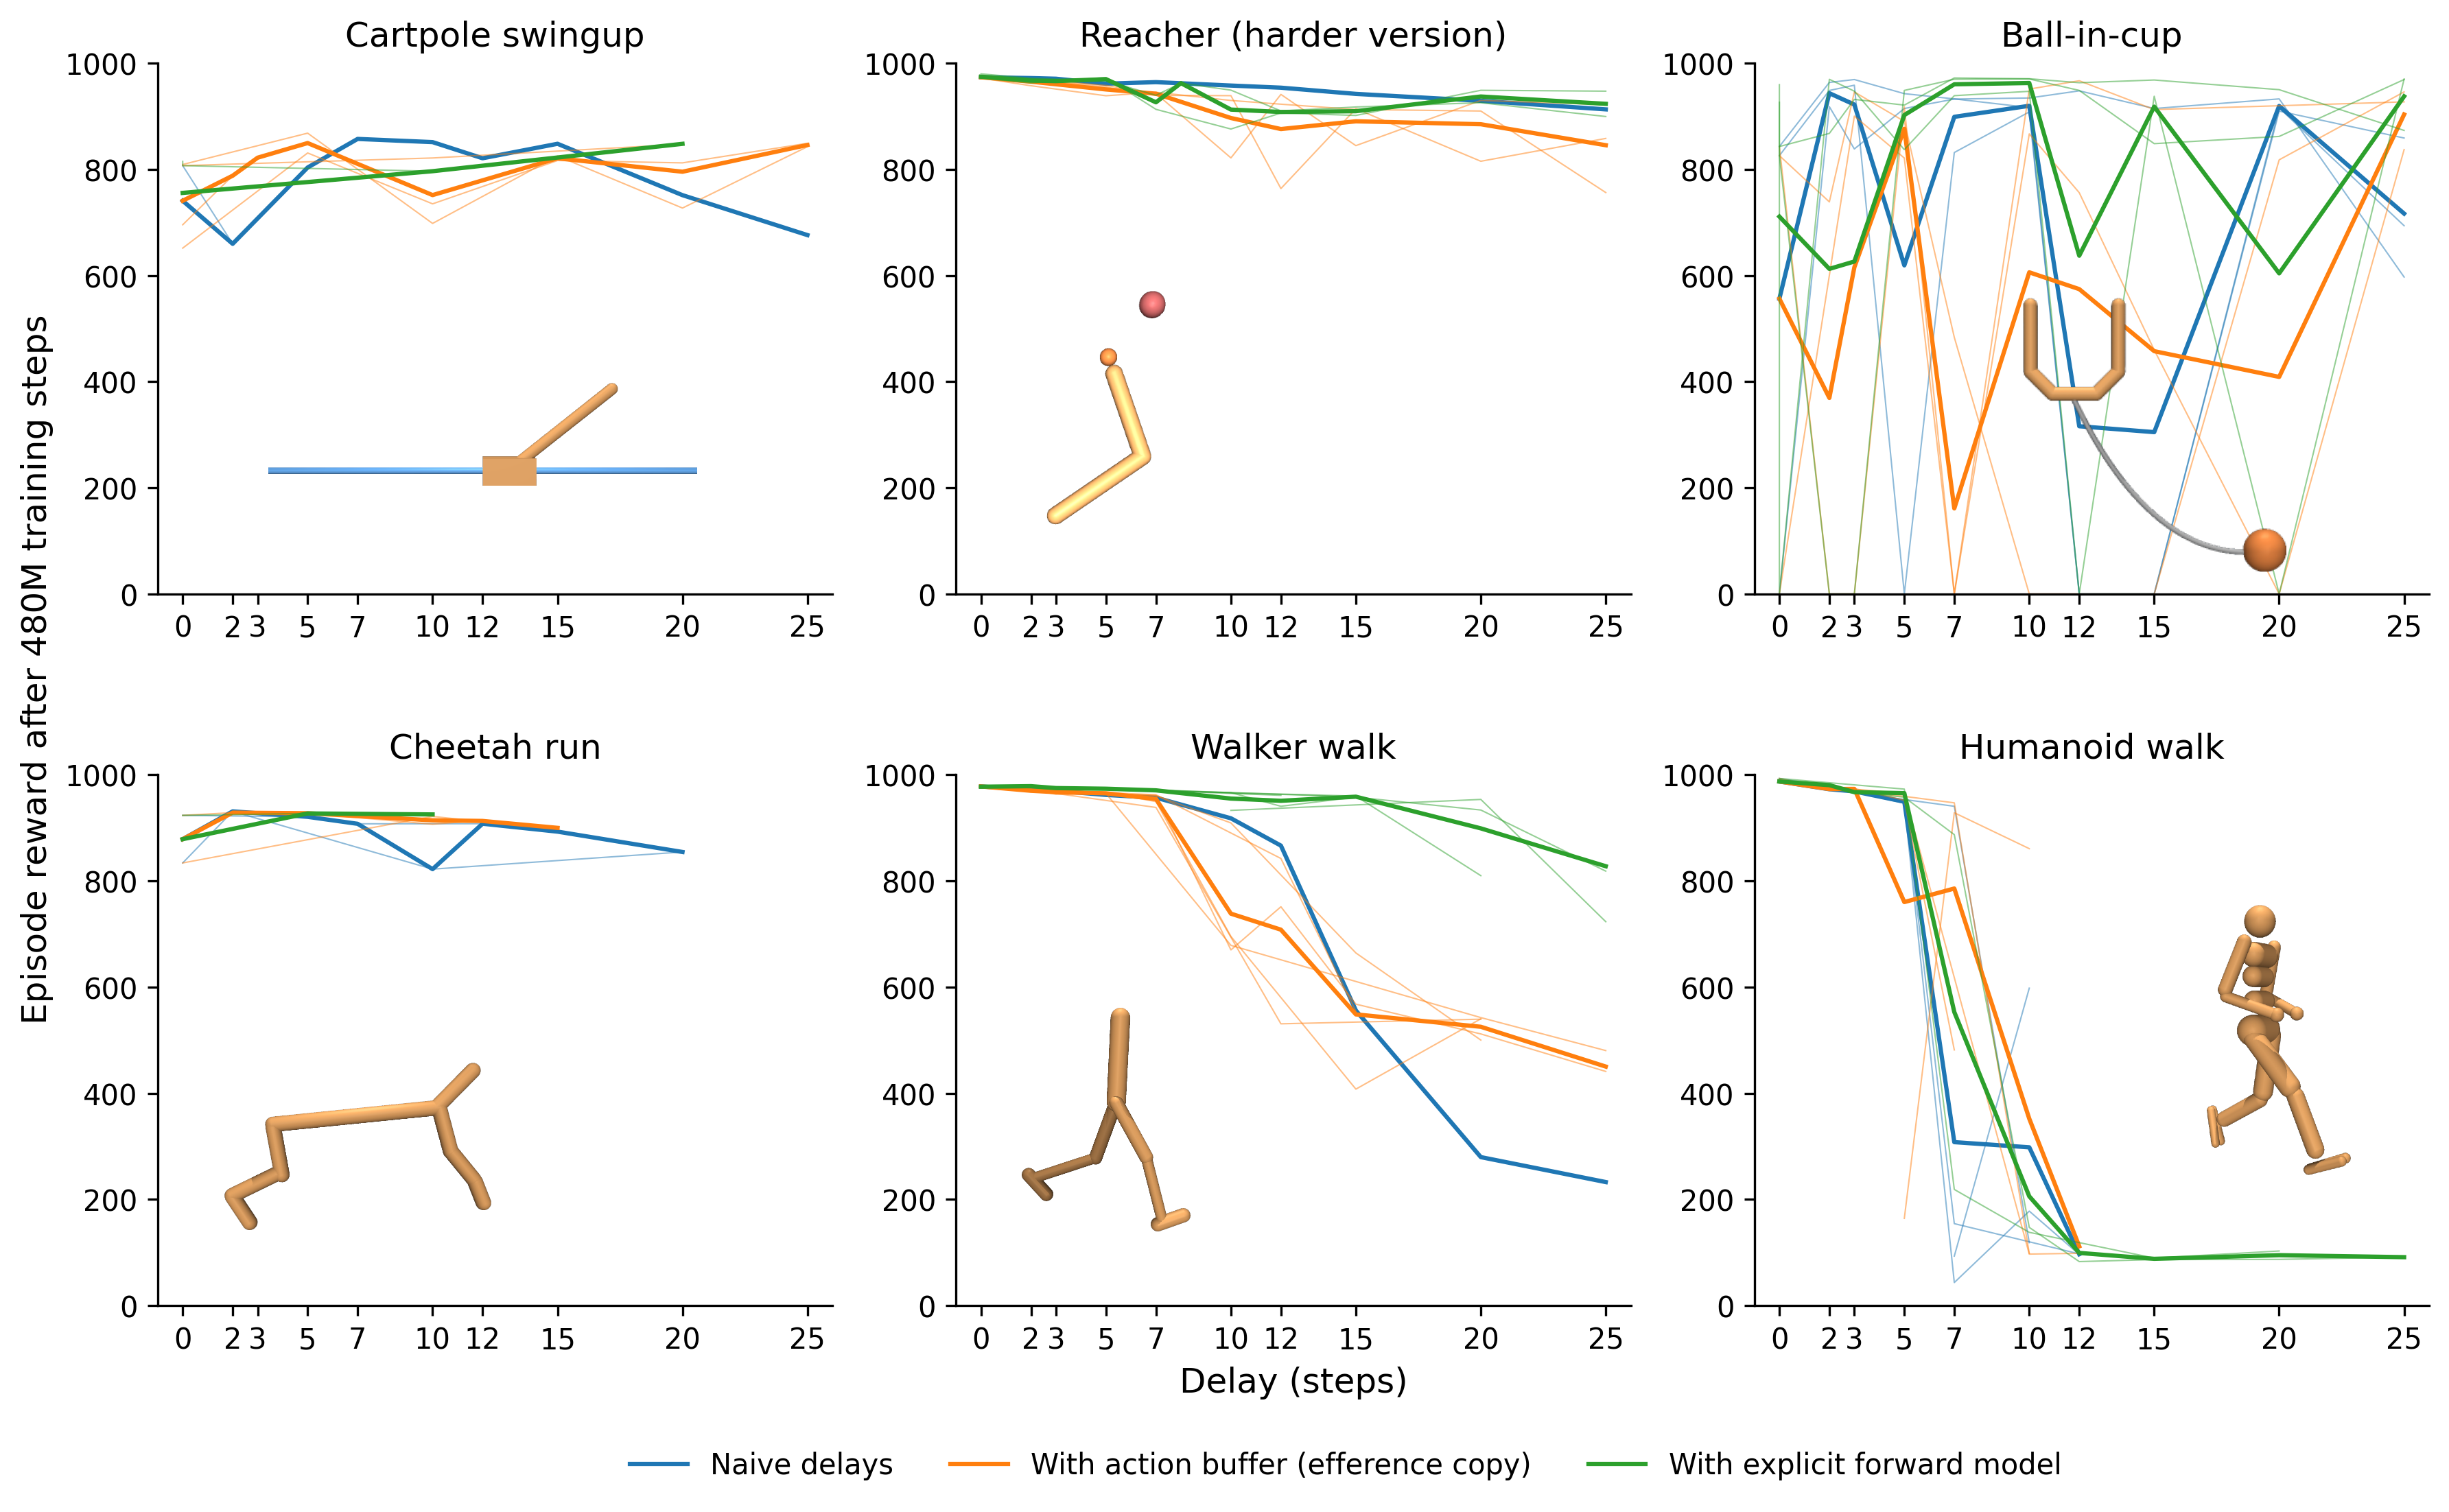

In [139]:
task_order = ["cartpole", "reacher", "ball_in_cup", "cheetah", "walker", "humanoid"]
condition_order = ["no_efference", "efference", "forward_model"]
label_images = {
    "cartpole": {"zoom": 0.15, "pos": (12, 300)},
    "reacher": {"zoom": 0.2, "pos": (5, 350)},
    "ball_in_cup": {"zoom": 0.4, "pos": (15, 300)},
    "cheetah": {"zoom": 0.12,"pos": (7, 300)},
    "walker": {"zoom": 0.12, "pos": (5, 350)},
    "humanoid": {"zoom": 0.15, "pos": (20, 500)},
}
titles = ["Cartpole swingup", "Reacher (harder version)", "Ball-in-cup", "Cheetah run", "Walker walk", "Humanoid walk"]
condition_labels = ["Naive delays", "With action buffer (efference copy)", "With explicit forward model"]
fig, axs = plt.subplots(2, 3, figsize=(12, 7), dpi=300)
for task, ax, title in zip(task_order, axs.flat, titles):
    task_data = data[data.task==task]
    for condition, color, condition_label in zip(condition_order, ["C0", "C1", "C2"], condition_labels):
        if condition == "foward_model":
            condition_data = task_data[task_data.condition == condition]
        else:
            condition_data = task_data[(task_data.condition == condition) | (task_data.condition == "undelayed")]
        grouped = condition_data.groupby("seed")
        for seed, seed_data in grouped:
            seed_data = seed_data.sort_values("delay")
            ax.plot(seed_data.delay, seed_data.reward_480M, color=color, lw=.5, alpha=0.5)
        mean = condition_data.groupby("delay").reward_480M.mean().sort_index()
        ax.plot(mean.index, mean.values, color=color, label=condition_label)
    im = Image.open(f"illustrations/{task}.png")
    im = matplotlib.offsetbox.OffsetImage(im, zoom=label_images[task]["zoom"])
    ax.add_artist(matplotlib.offsetbox.AnnotationBbox(im, label_images[task]["pos"], frameon=False))
    ax.set_title(title)
    ax.axis("auto")
    ax.set_ylim(0, 1000)
    ax.set_xlim(-1, 26)
    ax.set_xticks([0, 2, 3, 5, 7, 10, 12, 15, 20, 25])
axs[1,1].set_xlabel("Delay (steps)", fontsize=12)
axs[1,0].set_ylabel("Episode reward after 480M training steps", y=1.2, fontsize=12)
sns.despine(fig=fig)
plt.tight_layout()
axs[1,1].legend(loc=(-0.5, -0.35), ncol=3, frameon=False)
plt.show()

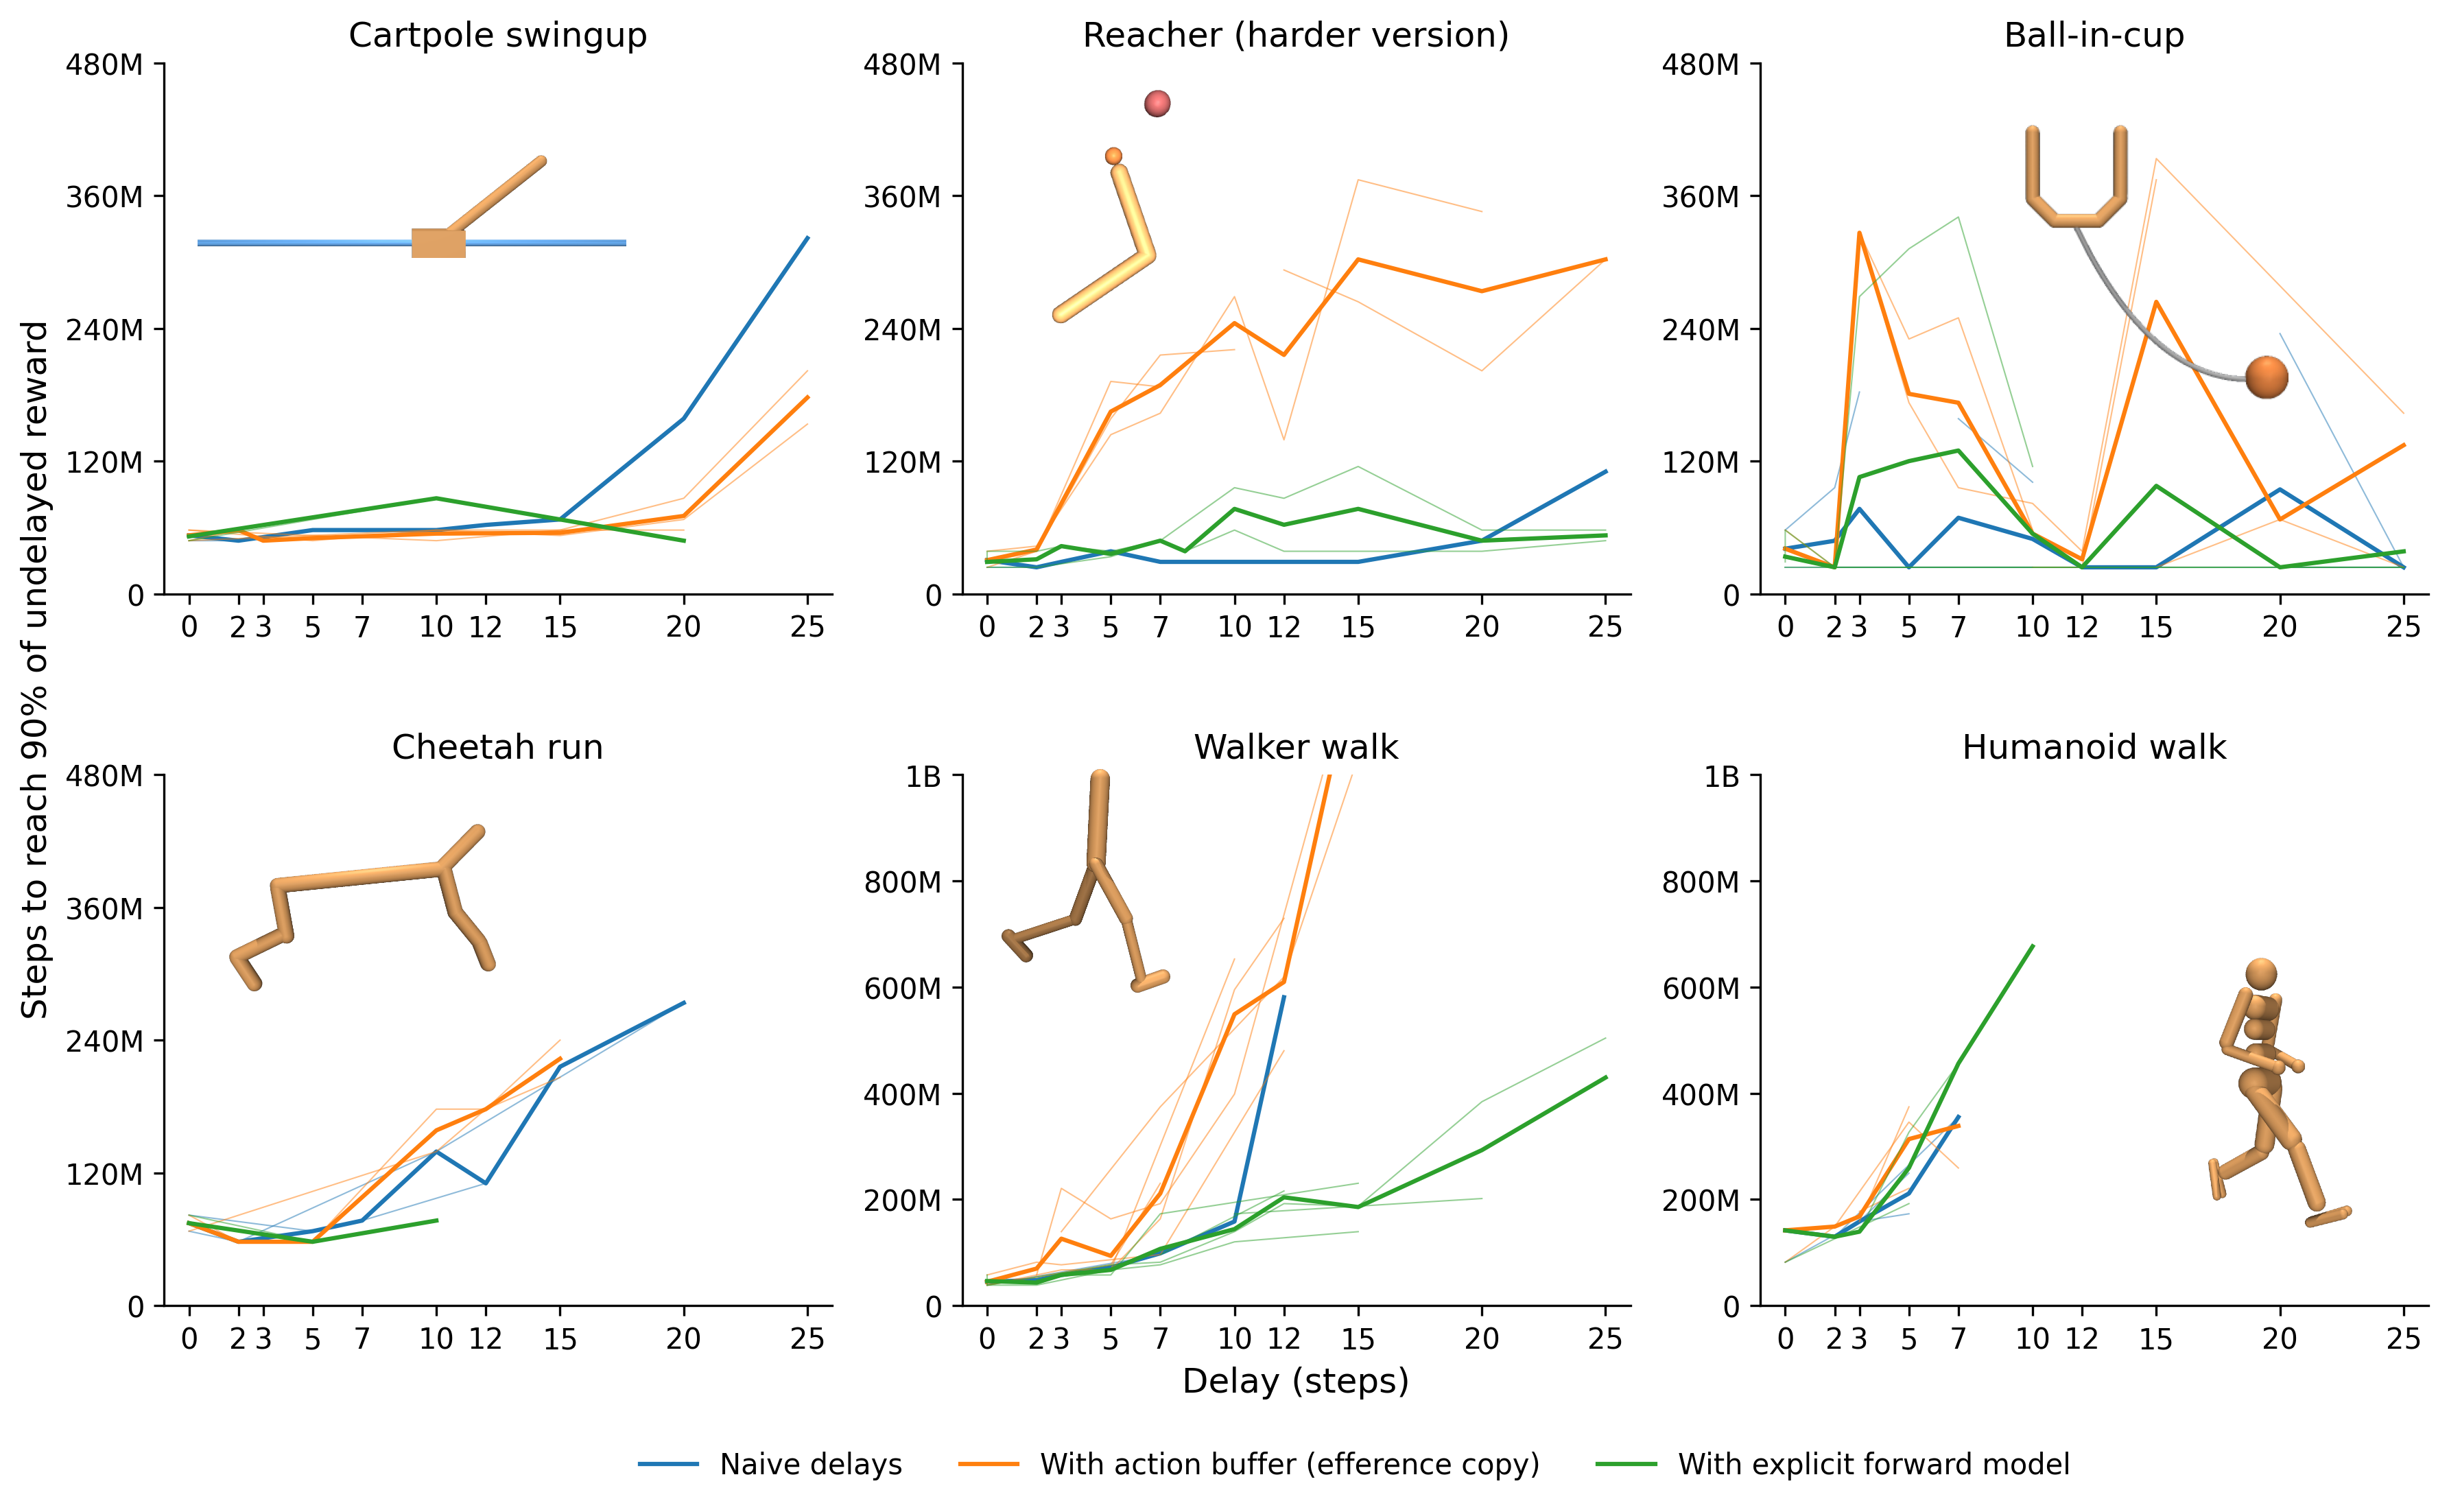

In [20]:
task_order = ["cartpole", "reacher", "ball_in_cup", "cheetah", "walker", "humanoid"]
condition_order = ["no_efference", "efference", "forward_model"]
label_images = {
    "cartpole": {"zoom": 0.15, "pos": (9, 3.5e8)},
    "reacher": {"zoom": 0.2, "pos": (5, 3.5e8)},
    "ball_in_cup": {"zoom": 0.4, "pos": (15, 3e8)},
    "cheetah": {"zoom": 0.12,"pos": (7, 3.6e8)},
    "walker": {"zoom": 0.12, "pos": (4, 8e8)},
    "humanoid": {"zoom": 0.15, "pos": (20, 4e8)},
}
titles = ["Cartpole swingup", "Reacher (harder version)", "Ball-in-cup", "Cheetah run", "Walker walk", "Humanoid walk"]
condition_labels = ["Naive delays", "With action buffer (efference copy)", "With explicit forward model"]
fig, axs = plt.subplots(2, 3, figsize=(12, 7), dpi=300)
for task, ax, title in zip(task_order, axs.flat, titles):
    task_data = data[data.task==task]
    for condition, color, condition_label in zip(condition_order, ["C0", "C1", "C2"], condition_labels):
        if condition == "foward_model":
            condition_data = task_data[task_data.condition == condition]
        else:
            condition_data = task_data[(task_data.condition == condition) | (task_data.condition == "undelayed")]
        grouped = condition_data.groupby("seed")
        for seed, seed_data in grouped:
            seed_data = seed_data.sort_values("delay")
            ax.plot(seed_data.delay, seed_data.steps_to_solve, color=color, lw=.5, alpha=0.5)
        mean = condition_data.groupby("delay").steps_to_solve.mean().sort_index()
        ax.plot(mean.index, mean.values, color=color, label=condition_label)
    im = Image.open(f"illustrations/{task}.png")
    im = matplotlib.offsetbox.OffsetImage(im, zoom=label_images[task]["zoom"])
    ax.add_artist(matplotlib.offsetbox.AnnotationBbox(im, label_images[task]["pos"], frameon=False))
    ax.set_title(title)
    ax.set_xlim(-1, 26)
    ax.set_xticks([0, 2, 3, 5, 7, 10, 12, 15, 20, 25])
    if task in ("walker", "humanoid"):
        ax.set_ylim(0, 1e9)
        ax.set_yticks(np.arange(6)*2e8)
        ax.set_yticklabels([0]+[f"{200*i}M" for i in range(1,5)]+["1B"])
    else:
        ax.set_ylim(0, 4.8e8)
        ax.set_yticks(np.arange(5)*1.2e8)
        ax.set_yticklabels([0]+[f"{120*i}M" for i in range(1,5)])
axs[1,1].set_xlabel("Delay (steps)", fontsize=12)
axs[1,0].set_ylabel("Steps to reach 90% of undelayed reward", y=1.2, fontsize=12)
sns.despine(fig=fig)
plt.tight_layout()
axs[1,1].legend(loc=(-0.5, -0.35), ncol=3, frameon=False)
plt.show()